# CDS Visualization

## Loading data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
import datetime


In [2]:
# Read CDS sheet from masterfile
#CDS_df = pd.read_excel('data/raw/data_masterfile.xlsx', sheet_name='CDS')
#CDS_df = CDS_df.rename(columns={'Dates': 'Date'})
#CDS_df['Date'] = pd.to_datetime(CDS_df['Date'])
#CDS_df.set_index('Date', inplace=True)
#CDS_df.columns = [col.replace('_USD', '') for col in CDS_df.columns]

CDS_df = pd.read_csv('data/raw/use_this_cds_data.csv')
CDS_df['Date'] = pd.to_datetime(CDS_df['Date'])
CDS_df.set_index('Date', inplace=True)

# Read Oil data from csv
Oil_df = pd.read_csv('data/raw/brent_ovx_weekly.csv')
Oil_df['Date'] = pd.to_datetime(Oil_df['Date'])
Oil_df.set_index('Date', inplace=True)

# Merge datasets
merged = pd.merge(CDS_df, Oil_df, on='Date', how='inner')
merged.head()


,Saudi Arabia,Russia,UAE,Abu Dhabi,Turkey,United States,Brazil,Mexico,Israel,Egypt,...,Qatar,Poland,Chile,Philippines,Bahrain,Argentina,Colombia,Morocco,Brent,OVX
Date,,,,,,,,,,,,,,,,,,,,,
2008-01-04,NaN,NaN,NaN,NaN,186.93,NaN,116.3,81.9,45.0,NaN,...,35.0,37.0,NaN,161.13,NaN,490.4,NaN,NaN,96.790001,34.500000
2008-01-11,NaN,NaN,NaN,NaN,188.36,NaN,115.3,82.9,45.0,NaN,...,35.0,40.0,NaN,192.75,NaN,486.4,NaN,NaN,91.070000,32.119999
2008-01-18,NaN,NaN,NaN,NaN,188.36,NaN,115.3,82.9,45.0,NaN,...,35.0,40.0,NaN,217.97,NaN,486.4,NaN,NaN,89.230003,31.459999
2008-01-25,NaN,NaN,NaN,NaN,188.36,NaN,115.3,82.9,45.0,NaN,...,35.0,40.0,NaN,208.20,NaN,486.4,NaN,NaN,90.900002,31.959999
2008-02-01,NaN,NaN,NaN,NaN,188.36,NaN,115.3,82.9,45.0,NaN,...,35.0,40.0,NaN,201.33,NaN,486.4,NaN,NaN,89.440002,29.770000


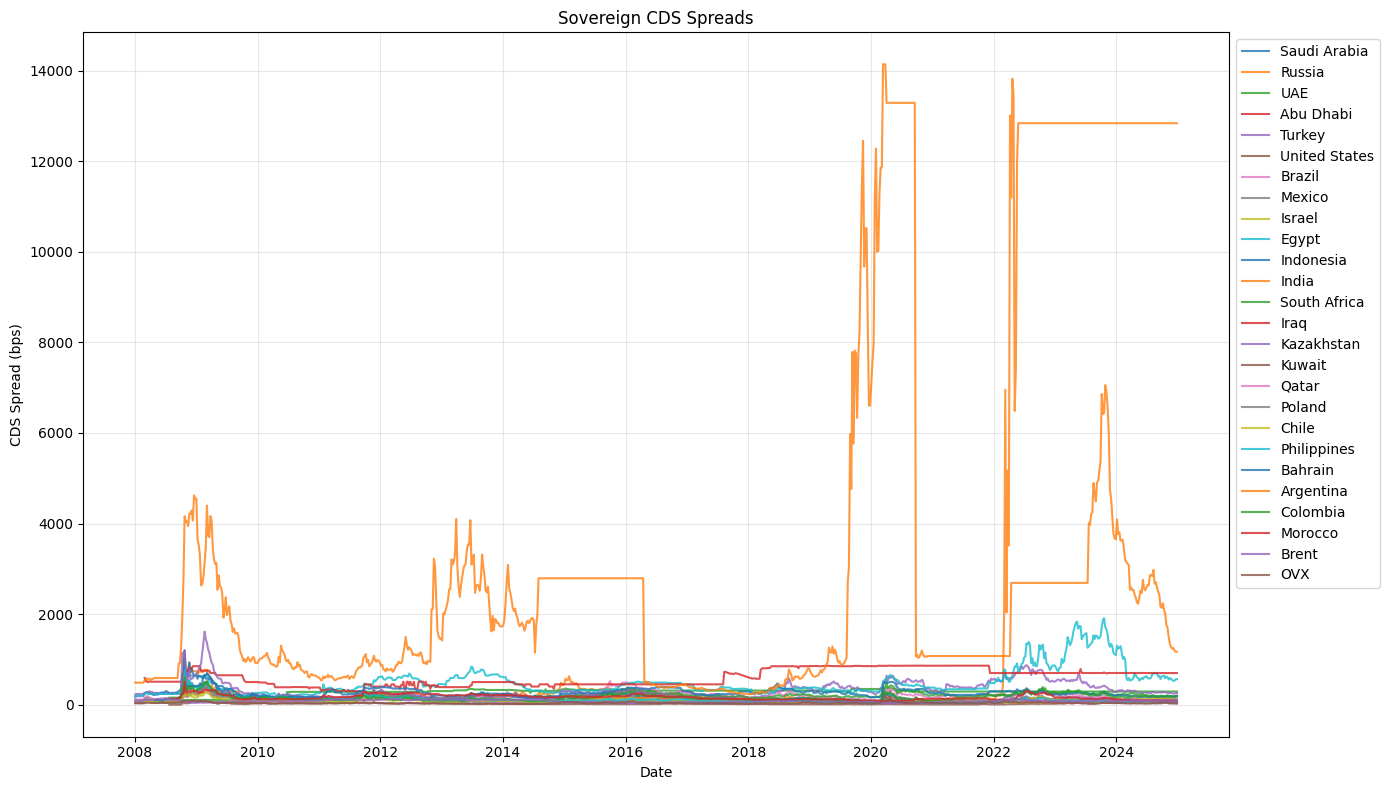

In [3]:
# Plot all CDS spreads
fig, ax = plt.subplots(figsize=(14, 8))

for col in merged.columns:
    ax.plot(merged.index, merged[col], label=col, alpha=0.8)

ax.set_xlabel('Date')
ax.set_ylabel('CDS Spread (bps)')
ax.set_title('Sovereign CDS Spreads')
ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### What CDS are sufficiently liquid?

In [4]:
# Check liquidity for recent period only (2018-2024)
recent = merged[merged.index >= datetime.datetime(2014,1,1)].copy()


print("=== LIQUIDITY CHECK (2018-2024) ===\n")

liquidity_recent = {}

for country in recent.columns:
    if country in ['Date', 'Brent', 'OVX']:
        continue
    
    returns = recent[country].pct_change().dropna()
    
    if len(returns) < 50:  # Skip if too few obs
        continue
    
    zero_pct = (returns == 0).sum() / len(returns) * 100
    
    is_zero = (returns == 0).astype(int)
    streaks = is_zero.groupby((is_zero != is_zero.shift()).cumsum()).sum()
    max_streak = streaks.max()
    
    liquidity_recent[country] = {
        'zero_pct': zero_pct,
        'max_streak': max_streak,
        'n_obs': len(returns)
    }

# Ranked
ranked = sorted(liquidity_recent.items(), key=lambda x: x[1]['zero_pct'])

for country, stats in ranked:
    status = "✓ LIQUID" if stats['zero_pct'] < 10 else "ILLIQUID" if stats['zero_pct'] > 30 else "  OK"
    print(f"{country:20s}: {stats['zero_pct']:5.1f}%, streak: {stats['max_streak']:3d}, n={stats['n_obs']}  {status}")

=== LIQUIDITY CHECK (2018-2024) ===

Colombia            :   0.0%, streak:   0, n=573  ✓ LIQUID
Turkey              :   0.2%, streak:   1, n=573  ✓ LIQUID
Mexico              :   0.2%, streak:   1, n=573  ✓ LIQUID
South Africa        :   0.2%, streak:   1, n=573  ✓ LIQUID
Brazil              :   0.3%, streak:   1, n=573  ✓ LIQUID
Chile               :   0.5%, streak:   1, n=573  ✓ LIQUID
Indonesia           :   0.9%, streak:   1, n=573  ✓ LIQUID
Bahrain             :   1.2%, streak:   1, n=573  ✓ LIQUID
Egypt               :   1.4%, streak:   2, n=573  ✓ LIQUID
Philippines         :   1.9%, streak:   5, n=573  ✓ LIQUID
Kazakhstan          :   3.0%, streak:   2, n=573  ✓ LIQUID
Qatar               :   3.7%, streak:   2, n=573  ✓ LIQUID
Saudi Arabia        :   4.5%, streak:   2, n=573  ✓ LIQUID
Poland              :   7.3%, streak:  14, n=573  ✓ LIQUID
Israel              :  13.6%, streak:  50, n=573    OK
United States       :  21.5%, streak:  30, n=573    OK
Russia              :  24.1

#### Who do we define as exporters and controls?

Oil prices:
 Year
2022    94.25
2023    77.70
2024    75.82
2025    64.27
2026    60.46
Name: Value, dtype: float64

GDP shape: (33, 25)

Crude oil balance shape: (62, 35)

Countries in crude oil file containing 'Turk':
['Turkey']

Crude oil balance (filtered):
Country Poland Kazakhstan Brazil Chile Colombia Mexico Indonesia Philippines  \
2020      25.0      -69.0  -61.6   7.5    -28.6  -59.0       7.0         3.8   
2021      24.2      -67.9  -56.3   8.2    -24.3  -53.4       8.9         3.7   
2022      27.3      -65.2  -55.7   7.4    -20.2  -49.2      12.1         5.6   
2023      25.4      -70.5  -69.7   8.9    -19.8  -52.3      14.3         6.3   
2024      27.1      -68.8  -69.0   9.9    -19.4  -40.7      13.1         5.6   

Country Egypt South Africa  Qatar Saudi Arabia  
2020      2.0         13.2  -42.3       -341.3  
2021      1.6          7.7  -41.0       -320.3  
2022      0.6          6.2  -41.8       -357.2  
2023     -3.5          7.3  -41.6       -321.0  
2024     -2.

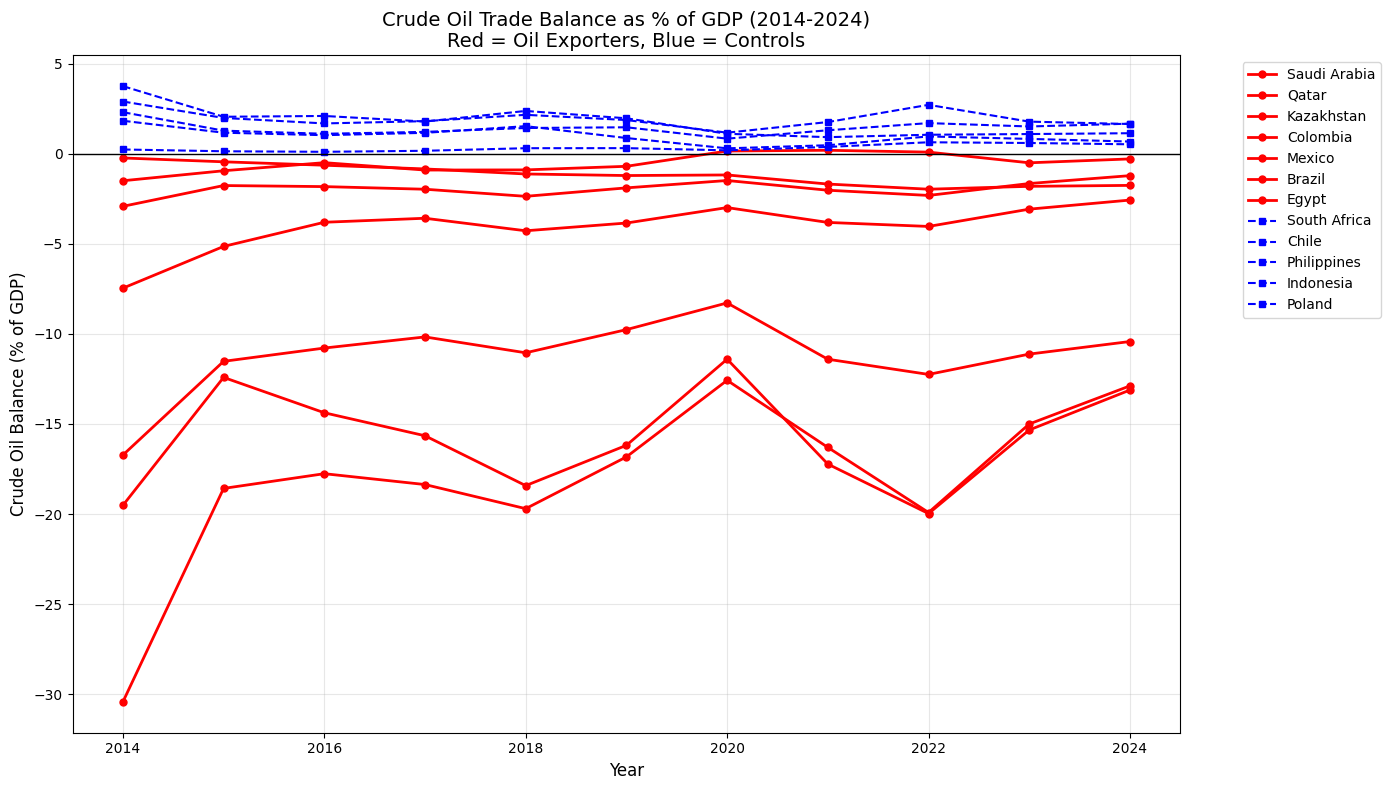


AVERAGE OIL BALANCE (% of GDP), 2014-2024
Saudi Arabia        : -18.03%  [EXPORTER]
Kazakhstan          : -15.79%  [EXPORTER]
Qatar               : -11.23%  [EXPORTER]
Colombia            : -4.06%  [EXPORTER]
Mexico              : -1.95%  [EXPORTER]
Brazil              : -1.17%  [EXPORTER]
Egypt               : -0.53%  [EXPORTER]
Indonesia           : +0.32%  [CONTROL]
Philippines         : +0.98%  [CONTROL]
Chile               : +1.44%  [CONTROL]
South Africa        : +1.76%  [CONTROL]
Poland              : +1.95%  [CONTROL]


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Constants
BARRELS_PER_TONNE = 7.33
TONNES_PER_MT = 1_000_000

# -----------------------------------------------------------------------------
# LOAD DATA
# -----------------------------------------------------------------------------

# Crude oil balance (need to handle apostrophe thousands separator)
crude_oil_balance = pd.read_csv('data/raw/trade_figures/crude_oil_trade_balance.csv', 
                                 thousands="'")
crude_oil_balance.set_index('Country', inplace=True)

# Oil prices
annual_oil_price = pd.read_csv('data/raw/oil_data/Annual_avg_price_of_oil_macrotrends.csv')
annual_oil_price['Year'] = pd.to_datetime(annual_oil_price['Date']).dt.year
oil_prices = annual_oil_price.set_index('Year')['Value']

# GDP (long format)
gdp_data = pd.read_csv('data/raw/gdp_figures/weo_gdp_ngdpd_annual_2000_2024_transformed.csv')

# Pivot GDP to wide format: index = country, columns = year
gdp_wide = gdp_data.pivot(index='country', columns='year', values='value')

print("Oil prices:\n", oil_prices.tail())
print("\nGDP shape:", gdp_wide.shape)
print("\nCrude oil balance shape:", crude_oil_balance.shape)

# -----------------------------------------------------------------------------
# MAP COUNTRY NAMES (they differ between files)
# -----------------------------------------------------------------------------

# Your selected countries (use names from crude oil file)
selected_countries_crude = ['Colombia', 'Turkey', 'Mexico', 'South Africa', 'Brazil', 
                            'Chile', 'Indonesia', 'Bahrain', 'Egypt', 'Philippines', 
                            'Kazakhstan', 'Qatar', 'Saudi Arabia', 'Poland']

# Note: crude oil file has "Turkiye" not "Turkey"
# Let's check what's actually in the file
print("\nCountries in crude oil file containing 'Turk':")
print([c for c in crude_oil_balance.index if 'Turk' in c])

# -----------------------------------------------------------------------------
# SELECT AND PREPARE DATA
# -----------------------------------------------------------------------------

# Filter crude oil balance to selected countries
# Map actual names from file
selected_in_crude = ['Colombia', 'Turkiye', 'Mexico', 'South Africa', 'Brazil', 
                     'Chile', 'Indonesia', 'Bahrain', 'Egypt', 'Philippines', 
                     'Kazakhstan', 'Qatar', 'Saudi Arabia', 'Poland']

crude_filtered = crude_oil_balance.loc[crude_oil_balance.index.isin(selected_in_crude)]

# Transpose: index = years, columns = countries
crude_filtered = crude_filtered.T
crude_filtered.index = crude_filtered.index.astype(int)

print("\nCrude oil balance (filtered):")
print(crude_filtered.tail())

# -----------------------------------------------------------------------------
# CONVERT MT TO USD BILLIONS
# -----------------------------------------------------------------------------



# After loading and filtering crude oil balance, convert to numeric
crude_filtered = crude_filtered.apply(pd.to_numeric, errors='coerce')

print(crude_filtered.dtypes)
print(crude_filtered.tail())
crude_oil_usd = crude_filtered.copy()
# Then do the conversion
for year in crude_oil_usd.index:
    if year in oil_prices.index:
        price = oil_prices[year]
        crude_oil_usd.loc[year] = crude_filtered.loc[year] * TONNES_PER_MT * BARRELS_PER_TONNE * price / 1e9
print("\nCrude oil in USD billions:")
print(crude_oil_usd.tail())

# -----------------------------------------------------------------------------
# PREPARE GDP (map country names and convert to billions)
# -----------------------------------------------------------------------------

# Filter to selected countries
gdp_filtered = gdp_wide.loc[gdp_wide.index.isin(selected_in_crude)]

# Transpose: index = years, columns = countries
gdp_transposed = gdp_filtered.T
gdp_transposed.index = gdp_transposed.index.astype(int)

# Convert to billions
gdp_transposed = gdp_transposed / 1e9

print("\nGDP in USD billions:")
print(gdp_transposed.tail())

# -----------------------------------------------------------------------------
# CALCULATE OIL BALANCE AS % OF GDP
# -----------------------------------------------------------------------------

common_years = crude_oil_usd.index.intersection(gdp_transposed.index)
common_countries = crude_oil_usd.columns.intersection(gdp_transposed.columns)

print(f"\nCommon years: {common_years.min()} - {common_years.max()}")
print(f"Common countries: {list(common_countries)}")

crude_aligned = crude_oil_usd.loc[common_years, common_countries]
gdp_aligned = gdp_transposed.loc[common_years, common_countries]

oil_balance_pct_gdp = (crude_aligned / gdp_aligned) * 100

print("\nOil Balance as % of GDP:")
print(oil_balance_pct_gdp.tail())

# -----------------------------------------------------------------------------
# PLOT
# -----------------------------------------------------------------------------

oil_exporters = ['Saudi Arabia', 'Qatar', 'Kazakhstan', 'Bahrain', 'Colombia', 'Mexico', 'Brazil', 'Egypt']
controls = ['Turkey', 'South Africa', 'Chile', 'Philippines', 'Indonesia', 'Poland']

start_year = 2014
end_year = 2024

oil_balance_plot = oil_balance_pct_gdp.loc[start_year:end_year]

fig, ax = plt.subplots(figsize=(14, 8))

for country in oil_exporters:
    if country in oil_balance_plot.columns:
        ax.plot(oil_balance_plot.index, oil_balance_plot[country], 
                'o-', color='red', linewidth=2, markersize=5, label=country)

for country in controls:
    if country in oil_balance_plot.columns:
        ax.plot(oil_balance_plot.index, oil_balance_plot[country], 
                's--', color='blue', linewidth=1.5, markersize=4, label=country)

ax.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Crude Oil Balance (% of GDP)', fontsize=12)
ax.set_title(f'Crude Oil Trade Balance as % of GDP ({start_year}-{end_year})\nRed = Oil Exporters, Blue = Controls', fontsize=14)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# -----------------------------------------------------------------------------
# SUMMARY TABLE
# -----------------------------------------------------------------------------

recent_years = [y for y in range(start_year, end_year + 1) if y in oil_balance_pct_gdp.index]
avg_balance = oil_balance_pct_gdp.loc[recent_years].mean().sort_values(ascending=True)  # ascending so exporters (negative) at top

print("\n" + "="*60)
print(f"AVERAGE OIL BALANCE (% of GDP), {start_year}-{end_year}")
print("="*60)

for country in avg_balance.index:
    group = "EXPORTER" if country in oil_exporters else "CONTROL"
    print(f"{country:20s}: {avg_balance[country]:+.2f}%  [{group}]")

### Credit Quality of treatment vs control

In [39]:
oil_exporters = ['SaudiArabia', 'Qatar', 'Kazakhstan', 'Bahrain', 'Colombia', 'Mexico', 'Brazil']
controls = ['Turkey', 'SouthAfrica', 'Chile', 'Philippines', 'Egypt', 'Indonesia', 'Poland']
# Filter to 2018+ and selected countries
final_df = merged[merged.index >= datetime.datetime(2018,1,1)][['Brent', 'OVX'] + oil_exporters + controls].copy()

print(f"Final sample: {final_df.shape}")
final_df.to_csv('final_sample.csv', index=True)

Final sample: (365, 16)


### Correlation between Oil Volatility and CDS returns

In [40]:
# Compute returns
final_df['oil_ret'] = final_df['OVX'].pct_change()

oil_down = final_df[final_df['oil_ret'] > 0]


# Correlations
print("=== OIL-CDS CORRELATIONS ===\n")
print("Oil Exporters:")
for country in oil_exporters:
    if country in final_df.columns:
        cds_ret = final_df[country].pct_change()
        corr = oil_down['oil_ret'].corr(oil_down[country].pct_change())
        print(f"  {country}: {corr:+.3f}")

print("\nControl Group:")
for country in controls:
    if country in final_df.columns:
        cds_ret = final_df[country].pct_change()
        corr = oil_down['oil_ret'].corr(oil_down[country].pct_change())
        print(f"  {country}: {corr:+.3f}")

=== OIL-CDS CORRELATIONS ===

Oil Exporters:
  SaudiArabia: +0.330
  Qatar: +0.378
  Kazakhstan: +0.378
  Bahrain: +0.388
  Colombia: +0.377
  Mexico: +0.425
  Brazil: +0.405

Control Group:
  Turkey: +0.239
  SouthAfrica: +0.357
  Chile: +0.273
  Philippines: +0.299
  Egypt: +0.332
  Indonesia: +0.359
  Poland: +0.231


## Jump detection

In [41]:
# 1. JUMP DETECTION
print("=== JUMP DETECTION ===\n")

jump_threshold = 2 #

def count_jumps(series, threshold=3):
    returns = series.pct_change().dropna()
    std = returns.std()
    jumps = (returns.abs() > threshold * std).sum()
    pct = jumps / len(returns) * 100
    return jumps, pct, len(returns)

print("Oil:")
j, p, n = count_jumps(final_df['Brent'],jump_threshold)
print(f"  Jumps: {j} ({p:.2f}%) out of {n} obs")

print("\nCDS:")
for country in oil_exporters:
    if country in final_df.columns:
        j, p, n = count_jumps(merged[country], jump_threshold)
        print(f"  {country}: {j} jumps ({p:.2f}%)")

=== JUMP DETECTION ===

Oil:
  Jumps: 15 (4.12%) out of 364 obs

CDS:
  SaudiArabia: 26 jumps (3.47%)
  Qatar: 37 jumps (4.18%)
  Kazakhstan: 11 jumps (1.24%)
  Bahrain: 31 jumps (3.57%)
  Colombia: 19 jumps (2.22%)
  Mexico: 26 jumps (2.93%)
  Brazil: 35 jumps (3.95%)


## Co-Jump

In [42]:
# 2. CO-JUMPS
print("\n=== CO-JUMP ANALYSIS ===\n")

oil_ret = merged['Brent'].pct_change()
oil_std = oil_ret.std()
oil_jumps = oil_ret.abs() > 2 * oil_std

print(f"Oil jump days: {oil_jumps.sum()}\n")

for group in [oil_exporters, controls]:

    if group is oil_exporters:
        print("Oil Exporters \n")
    elif group is controls:
        print("\nControls\n")

    for country in group:
        if country in merged.columns:
            cds_ret = merged[country].pct_change()
            cds_std = cds_ret.std()
            cds_jumps = cds_ret.abs() > 2 * cds_std
            
            # Co-jumps
            co_jumps = (oil_jumps & cds_jumps).sum()
            
            # Conditional probability
            p_cds_given_oil = co_jumps / oil_jumps.sum() if oil_jumps.sum() > 0 else 0
            p_cds_unconditional = cds_jumps.sum() / len(cds_jumps)
            
            ratio = p_cds_given_oil / p_cds_unconditional if p_cds_unconditional > 0 else 0
            
            print(f"{country}: P(CDS jump | oil jump) = {p_cds_given_oil:.1%}, unconditional = {p_cds_unconditional:.1%}, ratio = {ratio:.1f}x")


=== CO-JUMP ANALYSIS ===

Oil jump days: 39

Oil Exporters 

SaudiArabia: P(CDS jump | oil jump) = 12.8%, unconditional = 2.9%, ratio = 4.4x
Qatar: P(CDS jump | oil jump) = 20.5%, unconditional = 4.2%, ratio = 4.9x
Kazakhstan: P(CDS jump | oil jump) = 17.9%, unconditional = 1.2%, ratio = 14.5x
Bahrain: P(CDS jump | oil jump) = 15.4%, unconditional = 3.5%, ratio = 4.4x
Colombia: P(CDS jump | oil jump) = 20.5%, unconditional = 2.1%, ratio = 9.6x
Mexico: P(CDS jump | oil jump) = 28.2%, unconditional = 2.9%, ratio = 9.6x
Brazil: P(CDS jump | oil jump) = 30.8%, unconditional = 3.9%, ratio = 7.8x

Controls

Turkey: P(CDS jump | oil jump) = 25.6%, unconditional = 4.5%, ratio = 5.7x
SouthAfrica: P(CDS jump | oil jump) = 25.6%, unconditional = 4.4%, ratio = 5.8x
Chile: P(CDS jump | oil jump) = 23.1%, unconditional = 4.6%, ratio = 5.0x
Philippines: P(CDS jump | oil jump) = 20.5%, unconditional = 3.9%, ratio = 5.2x
Egypt: P(CDS jump | oil jump) = 15.4%, unconditional = 4.1%, ratio = 3.8x
Indones

In [43]:
# 3. ASYMMETRY TEST
print("\n=== ASYMMETRY TEST ===\n")

import statsmodels.api as sm

oil_ret = merged['Brent'].pct_change()
oil_neg = oil_ret.clip(upper=0)  # Only negative returns
oil_pos = oil_ret.clip(lower=0)  # Only positive returns

for group in [oil_exporters, controls]:

    if group is oil_exporters:
        print("Oil Exporters \n")
    elif group is controls:
        print("\nControls\n")

    for country in group:
        if country in merged.columns:
            cds_ret = merged[country].pct_change()
            
            # Align
            data = pd.DataFrame({
                'cds': cds_ret,
                'oil_neg': oil_neg,
                'oil_pos': oil_pos
            }).dropna()
            
            X = sm.add_constant(data[['oil_neg', 'oil_pos']])
            model = sm.OLS(data['cds'], X).fit()
            
            print(f"{country}:")
            print(f"  β_neg = {model.params['oil_neg']:.3f} (oil crashes)")
            print(f"  β_pos = {model.params['oil_pos']:.3f} (oil rallies)")
            print(f"  Asymmetry: {abs(model.params['oil_neg']) - abs(model.params['oil_pos']):.3f}")



=== ASYMMETRY TEST ===

Oil Exporters 

SaudiArabia:
  β_neg = -0.591 (oil crashes)
  β_pos = -0.084 (oil rallies)
  Asymmetry: 0.507
Qatar:
  β_neg = -0.792 (oil crashes)
  β_pos = 0.037 (oil rallies)
  Asymmetry: 0.755
Kazakhstan:
  β_neg = -1.283 (oil crashes)
  β_pos = 0.275 (oil rallies)
  Asymmetry: 1.008
Bahrain:
  β_neg = -0.659 (oil crashes)
  β_pos = 0.084 (oil rallies)
  Asymmetry: 0.575
Colombia:
  β_neg = -1.456 (oil crashes)
  β_pos = -0.114 (oil rallies)
  Asymmetry: 1.343
Mexico:
  β_neg = -1.338 (oil crashes)
  β_pos = -0.168 (oil rallies)
  Asymmetry: 1.170
Brazil:
  β_neg = -1.104 (oil crashes)
  β_pos = -0.027 (oil rallies)
  Asymmetry: 1.077

Controls

Turkey:
  β_neg = -0.607 (oil crashes)
  β_pos = 0.009 (oil rallies)
  Asymmetry: 0.598
SouthAfrica:
  β_neg = -0.690 (oil crashes)
  β_pos = -0.128 (oil rallies)
  Asymmetry: 0.562
Chile:
  β_neg = -1.068 (oil crashes)
  β_pos = -0.107 (oil rallies)
  Asymmetry: 0.962
Philippines:
  β_neg = -0.928 (oil crashes)
  β

In [44]:
# 4. TAIL DEPENDENCE
print("\n=== TAIL DEPENDENCE ===\n")

oil_ret = merged['Brent'].pct_change()

# Bottom 10% of oil returns (crashes)
threshold = oil_ret.quantile(0.05)
crash_days = oil_ret < threshold

print(f"Oil crash days (bottom 10%): {crash_days.sum()}\n")

print("Correlation during oil crashes vs. normal:")
for group in [oil_exporters, controls]:

    if group is oil_exporters:
        print("Oil Exporters \n")
    elif group is controls:
        print("\nControls\n")

    for country in group:
        if country in merged.columns:
            cds_ret = merged[country].pct_change()
            
            corr_crash = oil_ret[crash_days].corr(cds_ret[crash_days])
            corr_normal = oil_ret[~crash_days].corr(cds_ret[~crash_days])
            
            print(f"  {country}: crash = {corr_crash:+.3f}, normal = {corr_normal:+.3f}, diff = {corr_crash - corr_normal:+.3f}")


=== TAIL DEPENDENCE ===

Oil crash days (bottom 10%): 45

Correlation during oil crashes vs. normal:
Oil Exporters 

  SaudiArabia: crash = -0.528, normal = -0.106, diff = -0.421
  Qatar: crash = -0.451, normal = -0.095, diff = -0.356
  Kazakhstan: crash = -0.277, normal = -0.078, diff = -0.199
  Bahrain: crash = -0.486, normal = -0.044, diff = -0.442
  Colombia: crash = -0.420, normal = -0.225, diff = -0.194
  Mexico: crash = -0.419, normal = -0.212, diff = -0.208
  Brazil: crash = -0.493, normal = -0.149, diff = -0.344

Controls

  Turkey: crash = -0.248, normal = -0.096, diff = -0.152
  SouthAfrica: crash = -0.134, normal = -0.176, diff = +0.041
  Chile: crash = -0.346, normal = -0.171, diff = -0.175
  Philippines: crash = -0.386, normal = -0.149, diff = -0.237
  Egypt: crash = -0.300, normal = -0.021, diff = -0.280
  Indonesia: crash = -0.431, normal = -0.143, diff = -0.288
  Poland: crash = -0.235, normal = -0.024, diff = -0.211
